# Práctica Final NLP — Ejercicio 3: Entrenamiento y testeo del modelo de sentimiento

**Bootcamp IA · Módulo de NLP**

Con las reviews preprocesadas en el Ejercicio 2 entrenamos **dos modelos distintos** de
clasificación binaria del sentimiento (positivo / negativo). Tras compararlos por sus métricas,
elegimos el mejor.

Los modelos reciben a su entrada los textos codificados con un modelo de **bolsa de palabras
(bag-of-words)**. Justificamos los parámetros del vectorizer y tenemos en cuenta el **desbalanceo
de clases** detectado en el EDA.

## Contenido del notebook
1. Carga de los datos preprocesados
2. División en train y test
3. Vectorización (bag-of-words con TF-IDF)
4. Entrenamiento de dos modelos
5. Comparación de resultados
6. Elección del modelo

## 0. Librerías

In [1]:
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

## 1. Carga de los datos preprocesados

Cargamos el CSV generado en el Ejercicio 2, que ya contiene el texto limpio y la etiqueta
(`target`: 1 positivo, 0 negativo).

In [2]:
df = pd.read_csv('data/reviews_preprocesado.csv')
df['texto_limpio'] = df['texto_limpio'].fillna('').astype(str)

print('Reviews:', len(df))
print(df['sentimiento'].value_counts())
df[['texto_limpio', 'target']].head(3)

Reviews: 9482
sentimiento
positivo    9015
negativo     467
Name: count, dtype: int64


,texto_limpio,target
0,not much write exactly supposed filter pop sou...,1
1,product exactly quite affordable not realized ...,1
2,primary job device block breath would otherwis...,1


## 2. División en train y test

Separamos un 20% para test. Usamos **estratificación** (`stratify`) para que la proporción de
reviews positivas y negativas sea la misma en train y en test, algo necesario por el fuerte
desbalanceo del corpus.

In [3]:
X = df['texto_limpio']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Train:', len(X_train), ' Test:', len(X_test))
print('Proporción de positivos  train:', round(y_train.mean(), 3),
      ' test:', round(y_test.mean(), 3))

Train: 7585  Test: 1897
Proporción de positivos  train: 0.951  test: 0.951


## 3. Vectorización (bag-of-words con TF-IDF)

Codificamos el texto como **bolsa de palabras** ponderada con **TF-IDF**, que rebaja el peso de
las palabras muy comunes y resalta las más informativas. Justificación de los parámetros:

- `ngram_range=(1, 2)`: incluimos unigramas y bigramas. En el EDA vimos que los bigramas capturan
  expresiones de sentimiento (`works great`, `highly recommend`) que un solo término pierde.
- `min_df=5`: ignoramos palabras que aparecen en menos de 5 reviews (ruido y erratas), lo que
  reduce mucho la dimensionalidad.
- `max_df=0.9`: ignoramos términos presentes en más del 90% de las reviews, poco discriminativos.
- `sublinear_tf=True`: aplicamos escala logarítmica a la frecuencia, habitual en texto.

El vectorizer se **ajusta solo con train** y luego se aplica a test, para no filtrar información
del conjunto de test.

In [4]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.9,
                             sublinear_tf=True)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print('Matriz train:', X_train_vec.shape)
print('Matriz test :', X_test_vec.shape)
print('Tamaño del vocabulario:', len(vectorizer.vocabulary_))

Matriz train: (7585, 12042)
Matriz test : (1897, 12042)
Tamaño del vocabulario: 12042


## 4. Entrenamiento de dos modelos

Entrenamos dos clasificadores lineales habituales en texto, distintos en su forma de decidir:

- **Regresión logística**: modelo probabilístico.
- **SVM lineal** (`LinearSVC`): busca el margen de separación máximo.

En ambos usamos `class_weight='balanced'`, que da más peso a la clase minoritaria (negativa) de
forma inversa a su frecuencia. Así tratamos el desbalanceo de la misma manera en los dos modelos y
la comparación es justa.

In [5]:
modelos = {
    'Regresión logística': LogisticRegression(max_iter=1000,
                                              class_weight='balanced',
                                              random_state=RANDOM_STATE),
    'SVM lineal': LinearSVC(class_weight='balanced', max_iter=5000,
                            random_state=RANDOM_STATE),
}

predicciones = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train_vec, y_train)
    predicciones[nombre] = modelo.predict(X_test_vec)
    print('Entrenado:', nombre)

Entrenado: Regresión logística
Entrenado: SVM lineal


/Users/isma/.pyenv/versions/3.8.18/lib/python3.8/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


## 5. Comparación de resultados

Comparamos los dos modelos en test. Por el desbalanceo, el **accuracy no es suficiente** (un
modelo que prediga siempre "positivo" ya rondaría el 95%). Nos fijamos sobre todo en el
**F1 de la clase negativa** y en el **F1 macro**, que promedia ambas clases por igual.

In [6]:
filas = []
for nombre, pred in predicciones.items():
    rep = classification_report(y_test, pred, output_dict=True, zero_division=0)
    filas.append({
        'modelo': nombre,
        'accuracy': accuracy_score(y_test, pred),
        'precision_neg': rep['0']['precision'],
        'recall_neg': rep['0']['recall'],
        'f1_neg': rep['0']['f1-score'],
        'f1_macro': rep['macro avg']['f1-score'],
    })

comparativa = pd.DataFrame(filas).set_index('modelo').round(3)
comparativa

,accuracy,precision_neg,recall_neg,f1_neg,f1_macro
modelo,,,,,
Regresión logística,0.953,0.518,0.634,0.570,0.773
SVM lineal,0.960,0.627,0.452,0.525,0.752


Mostramos el informe de clasificación completo de cada modelo.

In [7]:
for nombre, pred in predicciones.items():
    print('=' * 60)
    print(nombre)
    print('=' * 60)
    print(classification_report(y_test, pred,
                                target_names=['negativo', 'positivo'],
                                zero_division=0))

Regresión logística
              precision    recall  f1-score   support

    negativo       0.52      0.63      0.57        93
    positivo       0.98      0.97      0.98      1804

    accuracy                           0.95      1897
   macro avg       0.75      0.80      0.77      1897
weighted avg       0.96      0.95      0.96      1897

SVM lineal
              precision    recall  f1-score   support

    negativo       0.63      0.45      0.53        93
    positivo       0.97      0.99      0.98      1804

    accuracy                           0.96      1897
   macro avg       0.80      0.72      0.75      1897
weighted avg       0.96      0.96      0.96      1897



Y sus matrices de confusión.

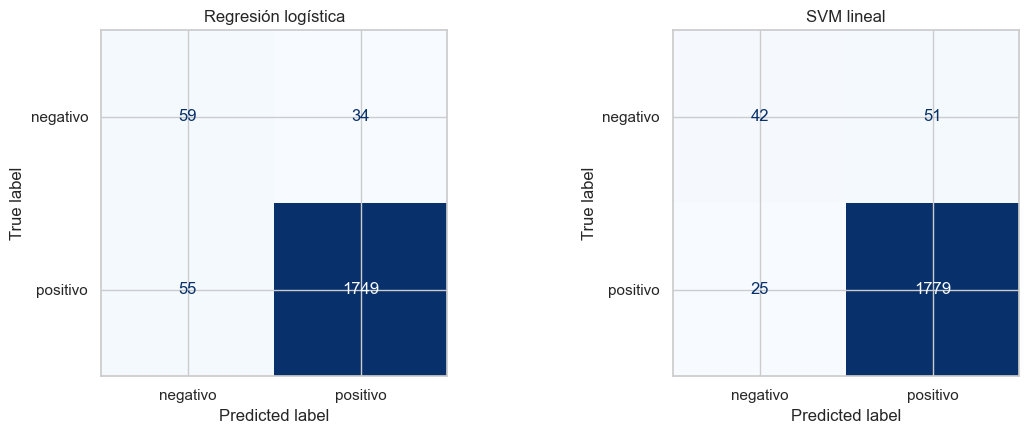

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (nombre, pred) in zip(axes, predicciones.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['negativo', 'positivo']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

## 6. Elección del modelo

Elegimos como mejor modelo el de **mayor F1 macro**, métrica adecuada cuando las clases están
desbalanceadas porque pondera por igual la clase positiva y la negativa.

In [9]:
mejor_nombre = comparativa['f1_macro'].idxmax()
mejor_modelo = modelos[mejor_nombre]

print('Modelo elegido:', mejor_nombre)
print('F1 macro:', round(comparativa.loc[mejor_nombre, 'f1_macro'], 3))
print('F1 clase negativa:', round(comparativa.loc[mejor_nombre, 'f1_neg'], 3))

Modelo elegido: Regresión logística
F1 macro: 0.773
F1 clase negativa: 0.57


Guardamos el vectorizer y el modelo elegido para usarlos directamente en el Ejercicio 4 sin
volver a entrenar.

In [10]:
joblib.dump(vectorizer, 'data/vectorizer.joblib')
joblib.dump(mejor_modelo, 'data/modelo_final.joblib')
print('Guardados data/vectorizer.joblib y data/modelo_final.joblib')

Guardados data/vectorizer.joblib y data/modelo_final.joblib


**Conclusión:** ambos modelos lineales ofrecen un rendimiento parecido sobre la bolsa de
palabras. Nos quedamos con el de mejor F1 macro, que equilibra el acierto en las dos clases pese al
desbalanceo. En el Ejercicio 4 analizamos este modelo en detalle y sacamos las conclusiones
finales.